In [1]:
pip install google-cloud-bigquery pandas

   ---------------------------------------- 0.0/3.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/3.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/3.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/3.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/3.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/3.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/3.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/3.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/3.5 MB ? eta -:--:--
   --- ------------------------------------ 0.3/3.5 MB ? eta -:--:--
   --- ------------------------------------ 0.3/3.5 MB ? eta -:--:--
   --- ------------------------------------ 0.3/3.5 MB ? eta -:--:--
   --- ------------------------------------ 0.3/3.5 MB ? eta -:--:--
   --- ------------------------------------ 0.3/3.5 MB ? eta -:--:--
   --- ---------------------------


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\Dell\Documents\AI AUTOMATION\venv\Scripts\python.exe -m pip install --upgrade pip


In [1]:
# Core
import os
import json
import numpy as np
import pandas as pd

# Fix for your error 👇
from dataclasses import dataclass

# Dates / utils
from datetime import datetime
from pathlib import Path

# BigQuery
from google.cloud import bigquery

# ML
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.ensemble import IsolationForest

# Stats
from scipy.stats import kruskal

# Env
from dotenv import load_dotenv

In [2]:
from dotenv import load_dotenv
import os

# Use the actual full path to my .env file
dotenv_path = r"C:\Users\Dell\Documents\AI AUTOMATION\venv\.env.txt"
print("Loading .env from:", dotenv_path)

load_dotenv(dotenv_path)

api_key = os.getenv("OPENAI_API_KEY")

if api_key is None:
    raise ValueError(
        "API key not found! Check the .env file exists and the path is correct."
    )
else:
    print("API key loaded successfully:", api_key[:5], "...")

Loading .env from: C:\Users\Dell\Documents\AI AUTOMATION\venv\.env.txt
API key loaded successfully: sk-pr ...


In [3]:
#Define API key file
from openai import OpenAI
import pandas as pd
import os
from datetime import datetime
import numpy as np
import json
import smtplib
from email.message import EmailMessage

client = OpenAI(api_key=api_key)

In [4]:
# Check for json key
import os
print(os.getenv("GOOGLE_APPLICATION_CREDENTIALS"))

bigquery-key.json


In [5]:
#load json key
from dotenv import load_dotenv
import os

load_dotenv()

from google.cloud import bigquery
client = bigquery.Client()

In [6]:
#Define Config
@dataclass
class Config:
    as_of_date: str = "2026-04-06"
    sample_limit: int = 10000
    k_min: int = 2
    k_max: int = 8
    final_k: int = 4
    anomaly_fraction: float = 0.03

CONFIG = Config()

In [7]:
query = f"""
WITH customer_orders AS (
    SELECT
        u.id AS customer_id,
        u.email,
        u.age,
        u.country,
        u.gender,
        DATE(u.created_at) AS customer_since,
        o.order_id,
        o.status AS order_status,
        DATE(o.created_at) AS order_date,
        oi.sale_price,
        p.category,
        p.department,
        p.brand
    FROM `bigquery-public-data.thelook_ecommerce.users` u
    LEFT JOIN `bigquery-public-data.thelook_ecommerce.orders` o
        ON u.id = o.user_id
    LEFT JOIN `bigquery-public-data.thelook_ecommerce.order_items` oi
        ON o.order_id = oi.order_id
    LEFT JOIN `bigquery-public-data.thelook_ecommerce.products` p
        ON oi.product_id = p.id
),

-- 🔹 Order intervals for behavioral metrics
order_intervals AS (
    SELECT
        user_id AS customer_id,
        DATE(created_at) AS order_date,
        LAG(DATE(created_at)) OVER (
            PARTITION BY user_id ORDER BY created_at
        ) AS prev_order_date
    FROM `bigquery-public-data.thelook_ecommerce.orders`
),

purchase_behavior AS (
    SELECT
        customer_id,
        AVG(DATE_DIFF(order_date, prev_order_date, DAY)) AS avg_days_between_orders,
        STDDEV(DATE_DIFF(order_date, prev_order_date, DAY)) AS purchase_interval_std
    FROM order_intervals
    WHERE prev_order_date IS NOT NULL
    GROUP BY customer_id
),

customer_summary AS (
    SELECT
        customer_id,
        email,
        age,
        gender,
        country,
        customer_since,

        COUNT(DISTINCT order_id) AS total_orders,
        COUNT(*) AS total_items,

        ROUND(SUM(sale_price), 2) AS total_revenue,
        ROUND(AVG(sale_price), 2) AS avg_item_price,

        MAX(order_date) AS last_order_date,
        MIN(order_date) AS first_order_date,

        DATE_DIFF(CURRENT_DATE(), MAX(order_date), DAY) AS days_since_last_order,

        DATE_DIFF(MAX(order_date), MIN(order_date), DAY) AS customer_lifespan_days,

        ROUND(
            COUNT(DISTINCT IF(order_status = 'Cancelled', order_id, NULL)) /
            NULLIF(COUNT(DISTINCT order_id), 0),
            4
        ) AS cancellation_rate,

        ROUND(
            SUM(sale_price) / NULLIF(COUNT(DISTINCT order_id), 0),
            2
        ) AS avg_order_value,

        -- 🔥 NEW: Order density (important behavioral signal)
       ROUND(
    COUNT(DISTINCT order_id) /
    NULLIF(DATE_DIFF(MAX(order_date), MIN(order_date), DAY), 0),
    4
) AS order_density

    FROM customer_orders
    WHERE order_id IS NOT NULL
    GROUP BY 1,2,3,4,5,6
),

-- 🔹 Preferences (top category / department / brand)
category_rank AS (
    SELECT
        customer_id,
        category,
        COUNT(*) AS cnt,
        ROW_NUMBER() OVER (
            PARTITION BY customer_id ORDER BY COUNT(*) DESC, category
        ) AS rn
    FROM customer_orders
    WHERE category IS NOT NULL
    GROUP BY customer_id, category
),

department_rank AS (
    SELECT
        customer_id,
        department,
        COUNT(*) AS cnt,
        ROW_NUMBER() OVER (
            PARTITION BY customer_id ORDER BY COUNT(*) DESC, department
        ) AS rn
    FROM customer_orders
    WHERE department IS NOT NULL
    GROUP BY customer_id, department
),

brand_rank AS (
    SELECT
        customer_id,
        brand,
        COUNT(*) AS cnt,
        ROW_NUMBER() OVER (
            PARTITION BY customer_id ORDER BY COUNT(*) DESC, brand
        ) AS rn
    FROM customer_orders
    WHERE brand IS NOT NULL
    GROUP BY customer_id, brand
)

SELECT
    cs.*,

    pb.avg_days_between_orders,
    pb.purchase_interval_std,

    -- 🔥 NORMALIZED METRICS
    ROUND(cs.total_orders / NULLIF(cs.customer_lifespan_days / 30.0, 0), 4) AS monthly_order_rate,
    ROUND(cs.total_revenue / NULLIF(cs.customer_lifespan_days, 0), 4) AS revenue_per_day,

    -- 🔹 Preferences
    cr.category AS favorite_category,
    dr.department AS favorite_department,
    br.brand AS favorite_brand,

    -- 🔹 Segments (baseline)
    CASE
        WHEN cs.days_since_last_order <= 30 THEN 'Active'
        WHEN cs.days_since_last_order <= 90 THEN 'Warm'
        WHEN cs.days_since_last_order <= 180 THEN 'Cooling'
        ELSE 'Dormant'
    END AS recency_segment,

    CASE
        WHEN cs.total_orders = 1 THEN 'One-time'
        WHEN cs.total_orders BETWEEN 2 AND 4 THEN 'Occasional'
        ELSE 'Frequent'
    END AS frequency_segment

FROM customer_summary cs

LEFT JOIN purchase_behavior pb
    ON cs.customer_id = pb.customer_id

LEFT JOIN category_rank cr
    ON cs.customer_id = cr.customer_id AND cr.rn = 1

LEFT JOIN department_rank dr
    ON cs.customer_id = dr.customer_id AND dr.rn = 1

LEFT JOIN brand_rank br
    ON cs.customer_id = br.customer_id AND br.rn = 1

ORDER BY cs.total_revenue DESC
LIMIT 10000
"""

df = client.query(query).to_dataframe(create_bqstorage_client=True)

print(df.shape)
df.head()

C:\Users\Dell\Documents\AI AUTOMATION\venv\Lib\site-packages\google\cloud\bigquery\table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


(10000, 26)


,customer_id,email,age,gender,country,customer_since,total_orders,total_items,total_revenue,avg_item_price,...,order_density,avg_days_between_orders,purchase_interval_std,monthly_order_rate,revenue_per_day,favorite_category,favorite_department,favorite_brand,recency_segment,frequency_segment
0,63421,ernestmarquez@example.net,69,M,Brasil,2023-08-26,4,7,1667.99,238.28,...,0.0062,214.333333,253.663820,0.1866,2.5941,Active,Men,Alpha Industries,Cooling,Occasional
1,14997,jesusstanton@example.org,22,M,China,2023-04-23,4,6,1573.94,262.32,...,0.0061,219.666667,306.862075,0.1821,2.3884,Outerwear & Coats,Men,Carhartt,Dormant,Occasional
2,6329,jasonwilliams@example.org,25,M,China,2022-01-11,4,6,1539.48,256.58,...,0.0031,428.000000,324.528889,0.0935,1.1990,Jeans,Men,Calvin Klein Jeans,Cooling,Occasional
3,39504,franciswiley@example.org,26,M,United States,2024-04-07,3,7,1487.11,212.44,...,0.0049,306.500000,297.691955,0.1468,2.4260,Jeans,Men,7 For All Mankind,Warm,Occasional
4,32816,leonardramos@example.net,39,M,France,2021-04-03,2,5,1475.32,295.06,...,0.0016,1229.000000,NaN,0.0488,1.2004,Shorts,Men,Alpha Industries,Dormant,Occasional


In [8]:
#data cleaning
import pandas as pd
import numpy as np

df = df.copy()

# Ensure correct types
df["customer_lifespan_days"] = df["customer_lifespan_days"].fillna(0)
df["avg_days_between_orders"] = df["avg_days_between_orders"].fillna(0)

# Remove customers with no orders or revenue issues
df = df[df["total_orders"] > 0]
df = df[df["total_revenue"] > 0]

In [9]:
# Remove very unstable customers (too new)
df = df[df["customer_lifespan_days"] >= 7]

# Stabilize ratios
df["safe_lifespan"] = df["customer_lifespan_days"].clip(lower=30)

df["monthly_order_rate"] = df["total_orders"] / (df["safe_lifespan"] / 30)
df["revenue_per_day"] = df["total_revenue"] / df["safe_lifespan"]

In [10]:
#Build ML features
features = [
    "total_revenue",
    "total_orders",
    "avg_order_value",
    "days_since_last_order",
    "avg_days_between_orders",
    "monthly_order_rate",
    "revenue_per_day"
]

In [11]:
#Log Transform (Reduce Skew
for col in ["total_revenue", "avg_order_value", "total_orders"]:
    df[f"log_{col}"] = np.log1p(df[col])

features += ["log_total_revenue", "log_avg_order_value", "log_total_orders"]

In [12]:
#Preprocessing + Scaling
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

X = df[features].copy()
Xs = pipeline.fit_transform(X)

In [13]:
#Find best k (Elbow + Silhouette)
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

scores = {}

for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(Xs)
    scores[k] = silhouette_score(Xs, labels)

print(scores)

{2: 0.300724340942597, 3: 0.3167433456583554, 4: 0.3441068882219643, 5: 0.31118407703977224, 6: 0.29993473043663843, 7: 0.30503949371357925, 8: 0.27886394979331613}


In [14]:
best_k = max(scores, key=scores.get)

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=20)
df["segment"] = kmeans.fit_predict(Xs)

In [15]:
#Anomaly flag
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.03, random_state=42)
df["anomaly_flag"] = (iso.fit_predict(Xs) == -1).astype(int)

In [16]:
segment_profile = df.groupby("segment").mean(numeric_only=True).round(2)

segment_profile

,customer_id,age,total_orders,total_items,total_revenue,avg_item_price,days_since_last_order,customer_lifespan_days,cancellation_rate,avg_order_value,order_density,avg_days_between_orders,purchase_interval_std,monthly_order_rate,revenue_per_day,safe_lifespan,log_total_revenue,log_avg_order_value,log_total_orders,anomaly_flag
segment,,,,,,,,,,,,,,,,,,,,
0,50272.32,40.99,2.03,4.02,362.74,101.72,502.57,554.19,0.15,179.27,0.01,538.24,475.32,0.25,1.45,554.19,5.88,5.18,1.11,0.00
1,49457.19,40.43,2.96,5.81,766.12,157.19,392.32,711.55,0.14,279.07,0.01,400.34,259.94,0.26,2.49,711.55,6.61,5.57,1.35,0.18
2,50030.19,40.93,3.64,5.88,393.70,71.26,310.4,800.9,0.15,109.16,0.01,308.37,234.43,0.26,0.94,800.9,5.95,4.68,1.53,0.00
3,49824.04,40.76,2.67,4.91,423.51,98.25,188.78,32.05,0.16,170.02,0.12,22.34,10.81,2.21,11.78,38.16,6.01,5.07,1.28,0.12


In [17]:
# Business Segmentation
def label_segment(row):
    if row["anomaly_flag"] == 1:
        return "Anomaly"

    # Dormant customers
    if row["days_since_last_order"] > 365:
        return "Dormant"

    # High value but at risk
    if row["avg_order_value"] > 200 and row["days_since_last_order"] > 180:
        return "High Value - At Risk"

    # Frequent but low spend
    if row["total_orders"] >= 3 and row["avg_order_value"] < 150:
        return "Frequent Low Spenders"

    # Active steady customers
    if row["monthly_order_rate"] >= 1:
        return "Active Core"

    return "Regular"
    

df["business_segment"] = df.apply(label_segment, axis=1)

In [18]:
#Decision Engine
def decision(row):
    # Always handle anomalies first
    if row["anomaly_flag"] == 1:
        return pd.Series(["no_action", "none", 0])

    # Dormant customers
    if row["days_since_last_order"] > 365:
        return pd.Series(["winback_discount", "email", 25])

    # High value but at risk
    if row["avg_order_value"] > 200 and row["days_since_last_order"] > 180:
        return pd.Series(["winback_vip_offer", "email", 20])

    # Frequent low spenders → increase basket size
    if row["total_orders"] >= 3 and row["avg_order_value"] < 150:
        return pd.Series(["bundle_offer", "push", 10])

    # Active core → maintain engagement
    if row["monthly_order_rate"] >= 1:
        return pd.Series(["cross_sell", "email", 5])

    return pd.Series(["no_action", "none", 0])


df[["action", "channel", "offer"]] = df.apply(decision, axis=1)

In [19]:
#Output decsion/customer segmentation and anomalies
df.to_csv("customer_decisions.csv", index=False)

anomaly_df = df[df["anomaly_flag"] == 1]
anomaly_df.to_csv("anomaly_customers.csv", index=False)

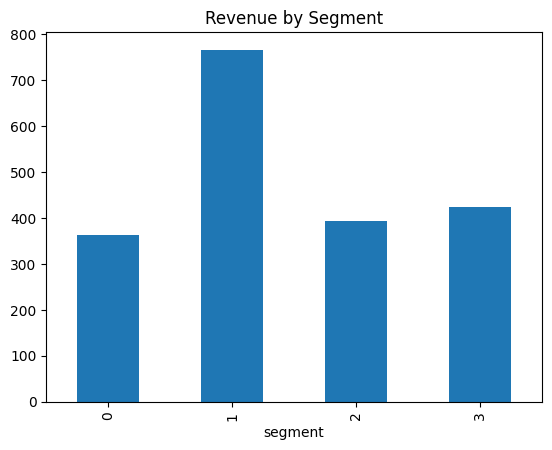

In [20]:
import matplotlib.pyplot as plt

df.groupby("segment")["total_revenue"].mean().plot(kind="bar")
plt.title("Revenue by Segment")
plt.show()

In [26]:
#Upload deecision table to Bigquery
from google.cloud import bigquery

client = bigquery.Client()

table_id = "sublime-amp-480104-g6.Analytics.Customer_Segmentation_Intelligence"

job = client.load_table_from_dataframe(df, table_id)
job.result()

C:\Users\Dell\Documents\AI AUTOMATION\venv\Lib\site-packages\google\cloud\bigquery\_pandas_helpers.py:486: FutureWarning: Loading pandas DataFrame into BigQuery will require pandas-gbq package version 0.26.1 or greater in the future. Tried to import pandas-gbq and got: No module named 'pandas_gbq'
  warnings.warn(


LoadJob<project=sublime-amp-480104-g6, location=US, id=2c3f1c9b-a7b5-4077-bc4e-e3310502dd3f>